# **ML PROJECT - EEG PD**
## Imports & Configuration

In [5]:
!pip install -q mne
!pip install captum
!pip install scikit-posthocs

In [6]:
import os
import warnings
import copy
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib.lines import Line2D

from scipy.stats import mode, pearsonr, entropy, pointbiserialr, zscore
import scipy.stats as stats
from scipy.spatial import ConvexHull
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.linear_model import LinearRegression
from sklearn.manifold import TSNE
from scipy.integrate import trapezoid
from scipy.signal import spectrogram
import scikit_posthocs as sp

import mne
from mne.time_frequency import psd_array_welch
from sklearn.neighbors import NearestNeighbors
from random import sample

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
import umap
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
	silhouette_score, davies_bouldin_score, calinski_harabasz_score,
	adjusted_rand_score, normalized_mutual_info_score, f1_score, confusion_matrix, ConfusionMatrixDisplay,
	classification_report, accuracy_score, roc_curve, auc, roc_auc_score, make_scorer, balanced_accuracy_score
)
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score, GroupKFold, cross_validate, GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC

import torch
import torch.nn as nn
from torch.utils.data import Dataset, TensorDataset, DataLoader, Subset, WeightedRandomSampler
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from collections import Counter

from imblearn.over_sampling import SMOTE

from captum.attr import IntegratedGradients
from sklearn.ensemble import RandomForestClassifier



In [7]:
plt.ioff()

All models are fixed with a random seed to ensure reproducibility. Importantly, the analysis deliberately relies on **multiple clustering algorithms and dimensionality reduction techniques** to avoid conclusions driven by a single method.

# 1. DATASET DISCOVERY & SANITY CHECKS

The dataset consists of **resting-state EEG recordings** from Parkinson’s disease patients and healthy controls. The overarching goal of the unsupervised analysis is **not classification**, but rather to characterize the **intrinsic geometry** of EEG feature space.

## Mount & Sanity checks

In [8]:
# Dual-mode setup: Colab + GitHub
from pathlib import Path
import sys
import os
import zipfile
import shutil
import pandas as pd

# Detect environment
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # Mount Drive
    from google.colab import drive
    drive.mount("/content/drive", force_remount=True)

    # Path to the folder
    SHARED_FOLDER = Path("/content/drive/MyDrive/ML Final Project Group 5 Machine Learning")

    # Runtime folder (Python working dir)
    PROJECT_ROOT = Path("/content")

    # Copy utils.py into runtime if missing
    if not (PROJECT_ROOT / "utils.py").exists():
        shutil.copy(SHARED_FOLDER / "utils.py", PROJECT_ROOT)

    # Copy CSV into runtime if missing
    if not (PROJECT_ROOT / "participants_clin_cog.csv").exists():
        shutil.copy(SHARED_FOLDER / "participants_clin_cog.csv", PROJECT_ROOT)
else:
    # Local or GitHub
    PROJECT_ROOT = Path.cwd()  # repo folder containing evrthing

sys.path.append(str(PROJECT_ROOT))
import utils

DATA_ROOT = PROJECT_ROOT / "data" / "ds004584"
DATA_ZIP = PROJECT_ROOT / "ds004584.zip"
DATA_URL = "https://nemar.org/dataexplorer/download?filepath=/data/nemar/openneuro//zip_files/ds004584.zip"

# Download EEG zip if missing
if not DATA_ZIP.exists() and not DATA_ROOT.exists():
    print("Downloading EEG dataset...")
    os.system(f"wget -O {DATA_ZIP} '{DATA_URL}'")

# Extract dataset if missing
if not DATA_ROOT.exists():
    print("Extracting EEG dataset...")
    with zipfile.ZipFile(DATA_ZIP, "r") as z:
        # The zip contains folder ds004584 inside, extract into data/
        z.extractall(PROJECT_ROOT / "data")

CSV_FILE = PROJECT_ROOT / "participants_clin_cog.csv"
raw_csv = pd.read_csv(CSV_FILE)

set_files = sorted(DATA_ROOT.glob("sub-*/eeg/*.set"))

print(f"Running in Colab: {IN_COLAB}")
print(f"Subjects found: {len(set_files)}")
print(f"First 3 EEG files: {set_files[:3]}")

Mounted at /content/drive
Extracting EEG dataset...
Running in Colab: True
Subjects found: 149
First 3 EEG files: [PosixPath('/content/data/ds004584/sub-001/eeg/sub-001_task-Rest_eeg.set'), PosixPath('/content/data/ds004584/sub-002/eeg/sub-002_task-Rest_eeg.set'), PosixPath('/content/data/ds004584/sub-003/eeg/sub-003_task-Rest_eeg.set')]


In [9]:
RANDOM_STATE = utils.RANDOM_STATE
set_files = sorted(DATA_ROOT.glob("sub-*/eeg/*.set"))
print(f"Found {len(set_files)} EEG recordings")

Found 149 EEG recordings


In [10]:
# Load one example recording (sanity check only)
example_file = set_files[0]
raw = mne.io.read_raw_eeglab(example_file, preload=False, verbose=False)

print("Sampling frequency:", raw.info["sfreq"])
print("Number of channels:", len(raw.ch_names))
print("Duration (seconds):", raw.n_times / raw.info["sfreq"])
print("First 10 channel names:", raw.ch_names[:10])

Sampling frequency: 500.0
Number of channels: 63
Duration (seconds): 281.66
First 10 channel names: ['Fp1', 'Fz', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'TP9']


## Participants, labels and cognitive scores

We ask whether latent structure emerges naturally from the data, and if so, whether this structure aligns with disease diagnosis or clinical variables such as age, cognition (MOCA), or motor severity (UPDRS).

In [11]:
cognitive_cols = ['NIH FICAT', 'NIH DCCST', 'NIH PCPST', 'NIH PSMT','NIH PVT']

# Keep only rows where all cognitive tests are not NaN
participants, set_files, valid_subjects = utils.sync_eeg_and_metadata(raw_csv, DATA_ROOT)

print(participants["GROUP"].value_counts())

Sync Complete: 138 subjects with clinical scores and EEG files.
GROUP
PD         92
Control    46
Name: count, dtype: int64


In [12]:
age = participants.loc[participants["participant_id"].isin([f.parts[-3] for f in set_files]),"AGE"].values
moca = participants.loc[participants["participant_id"].isin([f.parts[-3] for f in set_files]),"MOCA"].values
updrs = participants.loc[participants["participant_id"].isin([f.parts[-3] for f in set_files]),"UPDRS"].values
nih_ficat = participants.loc[participants["participant_id"].isin([f.parts[-3] for f in set_files]),"NIH FICAT"].values


# Sanity check
if len(age) == len(valid_subjects):
  print("AGE vector shape:", age.shape)
else:
  raise ValueError("AGE vector length mismatch")

y_true = participants.set_index("participant_id").loc[valid_subjects, "GROUP"].values

AGE vector shape: (138,)


## Common channels

In [13]:
def load_eeg(file_path: Path) -> mne.io.Raw:
  # Load using mne
  return mne.io.read_raw_eeglab(
    file_path,
    preload=True,
    verbose=False
  )

In [14]:
# Determine common channel set (intersection across subjects)
common_channels = utils.get_common_channels(set_files)
print(f"There are {len(common_channels)} channels common to all {len(set_files)} subjects.")

There are 60 channels common to all 138 subjects.


In [15]:
print(utils.SELECTED_CHANNELS)

['P8', 'PO7', 'CP1', 'CP2', 'P6', 'O2', 'P4', 'F4']


## Global cognitive score

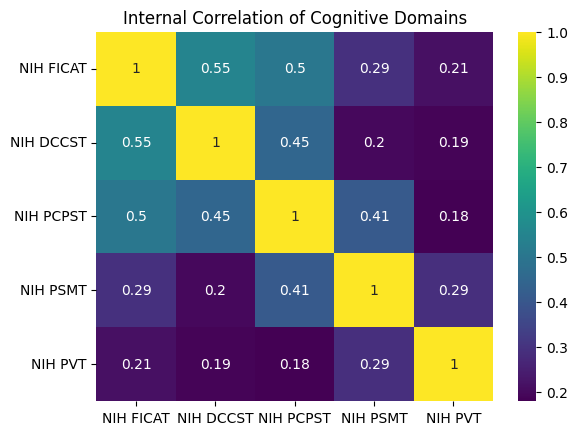

In [16]:
# Check how well the NIH scores correlate with each other
internal_corr = participants[cognitive_cols].corr()

sns.heatmap(internal_corr, annot=True, cmap='viridis')
plt.title("Internal Correlation of Cognitive Domains")
plt.show()

FICAT, DCCST, and PCPST are all strongly inter-correlated ($0.45$ to $0.55$). These three tests (Inhibitory Control, Cognitive Flexibility, and Processing Speed) are clearly moving together. They represent a "Frontal-Executive" core.PSMT and PVT have much weaker ties to that core (dropping as low as $0.18$). These measure Memory and Vocabulary/Vision, which are likely being preserved or affected differently in the group.

In [17]:
# Z-scores for EVERYONE based on Control Norms
participants = utils.get_processed_participants(participants)

In [18]:
print(f"-  CLINICAL LABEL SUMMARY (N={len(participants)})  -")
print("\nGroup Breakdown of Tiers (0=Preserved, 1=Standard, 2=Impaired):")
print(participants.groupby('GROUP')['cog_tier'].value_counts().unstack().fillna(0).astype(int))

print()
print("Binary Distribution (1=Impaired, 0=Not_Impaired):")
binary_counts = participants.groupby('GROUP')['cog_binary'].value_counts().unstack().fillna(0).astype(int)
binary_counts.columns = ['Not_Impaired (0)', 'Impaired (1)']
print(binary_counts)

-  CLINICAL LABEL SUMMARY (N=138)  -

Group Breakdown of Tiers (0=Preserved, 1=Standard, 2=Impaired):
cog_tier   0   1   2
GROUP               
Control   20  23   3
PD        12  36  44

Binary Distribution (1=Impaired, 0=Not_Impaired):
         Not_Impaired (0)  Impaired (1)
GROUP                                  
Control                43             3
PD                     48            44


To establish a biologically grounded ground-truth for cognitive status, participants were categorized using a normative-referenced composite score targeting the frontal-executive domain. Recognizing that Inhibitory Control (FICAT), Cognitive Flexibility (DCCST), and Processing Speed (PCPST) exhibited strong inter-correlation ($r = 0.45$ to $0.55$), an Executive Composite was calculated. This was achieved by transforming raw scores into Z-scores based exclusively on the distribution of the Healthy Control cohort ($N=46$). By using the healthy population as the baseline yardstick, we ensured that "Impairment" was defined not by arbitrary clusters, but by significant deviation from neurotypical performance. Specifically, a threshold of $Z < -1.0$ (representing the bottom 15% of healthy performance) was used to define Clinical Impairment (Tier 0), while $Z \ge 0$ identified Preserved function (Tier 2). This rigorous stratification provides a stable clinical anchor for the subsequent unsupervised EEG clustering, allowing us to test whether natural brain-wave patterns respect these established clinical boundaries.

# 2. CORE PROCESSING UTILITIES + FEATURE CONSTRUCTION

## Feature construction

In [19]:
FEATURES = utils.construct_master_features(set_files, utils.SELECTED_CHANNELS)

print()
print("-  FINAL INTEGRITY CHECK  -")
for key, data in FEATURES.items():
  print(f"Set: {key} | Shape: {data.shape}")

Starting processing for 138 files...


100%|██████████| 138/138 [00:41<00:00,  3.30it/s]


-  FINAL INTEGRITY CHECK  -
Set: full_psd | Shape: (138, 1288)
Set: low_freq | Shape: (138, 33)
Set: sham_band | Shape: (138, 32)


In [20]:
profile_cols = utils.get_feature_names()
# Verify the length matches data columns (Should be 33)
print(f"Total Features: {len(profile_cols)}")

Total Features: 33


Sizes ok:

low_freq = $(8 \text{ channels} \times 3 \text{ bands}) + 8 \text{ per-channel TARs} + 1 \text{ Global TAR} = \mathbf{33}$

sham_band =  $(8 \text{ channels} \times 4 \text{ bands}) $ = 32

## Outlier Id

In [21]:
subs_list, outlier_ids, participants = utils.clean_outliers(FEATURES, valid_subjects, participants, random_state=utils.RANDOM_STATE)

print(f"--- CLEANING COMPLETE ---")
print(f"Removed: {len(outlier_ids)} subjects: {outlier_ids} ")
print(f"New total N: {len(participants)} (PD: {sum(participants['GROUP']=='PD')}, Control: {sum(participants['GROUP']=='Control')})")

--- CLEANING COMPLETE ---
Removed: 7 subjects: ['sub-002', 'sub-003', 'sub-014', 'sub-082', 'sub-087', 'sub-095', 'sub-115'] 
New total N: 131 (PD: 86, Control: 45)


## Feature Engineering & Normalization

In [22]:
FEATURES_SCALED, y_binary, y_tiered, y_diag = utils.prepare_staged_data(FEATURES, participants, subs_list)

# CNN

## Definition

In [23]:
diagnosis_lookup = dict(zip(participants['participant_id'], participants['GROUP']))
label_lookup = dict(zip(participants['participant_id'], participants['cog_binary']))
tier_lookup  = dict(zip(participants['participant_id'], participants['cog_tier']))

In [24]:
sfreq = 500 #sampling frequancy
window_sec = 4 #size of the time window
overlap_ratio = 0.5 #overlap between the windows
fmin, fmax = 0.5, 12  #12Hz band pass filter for relevant cognitive frequancies

window_samples = int(window_sec * sfreq) #the ammount of window samples
step = int(window_samples * (1 - overlap_ratio)) #whole window segmentation

In [25]:
#We computed spectrograms for each subject (8 electrodes per subject, 149 samples)
#We devided the full EEG recordings for several time windows (4 sec windows from whole recording, meaning that every subject will get about 30 windows per subject (8Channels, Frequancy, Time))

unique_subject_ids = {uid: i for i, uid in enumerate(participants['participant_id'].unique())}

X_cnn = []
y_cnn = [] # Binary: 0 (Preserved), 1 (Impaired)
y_tier_cnn = [] # Tiered: 0 (Preserved), 1 (Standard), 2 (Risk)
groups_cnn = []


for file_path in tqdm(set_files):
  subj_id = file_path.parts[-3]
  if subj_id not in label_lookup: continue

  try:
    raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
    raw.pick_channels(utils.SELECTED_CHANNELS)
    raw.reorder_channels(utils.SELECTED_CHANNELS)
    EEG_data = raw.get_data()[:, :120*sfreq]

    bin_label = label_lookup[subj_id]
    tier_label = tier_lookup[subj_id]
    mapped_group_id = unique_subject_ids[subj_id]
#window bands (for several windows per subject)
    for start in range(0, EEG_data.shape[1] - window_samples + 1, step):
      window_chunk = EEG_data[:, start:start+window_samples]
      specs = []
      for ch in range(window_chunk.shape[0]):
        f, t, Sxx = spectrogram(window_chunk[ch, :], fs=sfreq, nperseg=500, noverlap=375)
        # Windowing 12Hz
        mask_f = (f >= fmin) & (f <= fmax)
        Sxx_log = 10 * np.log10(Sxx[mask_f, :] + 1e-10).astype(np.float32)#db
        specs.append(Sxx_log)#combine all 8 electrodes per subject (for each time window)

      X_cnn.append(np.stack(specs, axis=0))
      y_cnn.append(bin_label)
      y_tier_cnn.append(tier_label)
      groups_cnn.append(mapped_group_id)
  except Exception as e:
    continue

X_cnn = np.array(X_cnn, dtype=np.float32)
y_cnn = np.array(y_cnn, dtype=np.float32)
groups_cnn = np.array(groups_cnn)

# Subject-Level Normalization (within subject normalization, no usage of test data, no training-test information shared)
for g in np.unique(groups_cnn):
  mask = (groups_cnn == g)
  m, s = X_cnn[mask].mean(), X_cnn[mask].std() + 1e-7
  X_cnn[mask] = (X_cnn[mask] - m) / s

  0%|          | 0/138 [00:00<?, ?it/s]

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


  1%|          | 1/138 [00:00<00:55,  2.47it/s]

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


  3%|▎         | 4/138 [00:00<00:23,  5.65it/s]

...

 99%|█████████▊| 136/138 [00:46<00:00,  3.04it/s]

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


 99%|█████████▉| 137/138 [00:46<00:00,  2.89it/s]

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


100%|██████████| 138/138 [00:47<00:00,  2.92it/s]


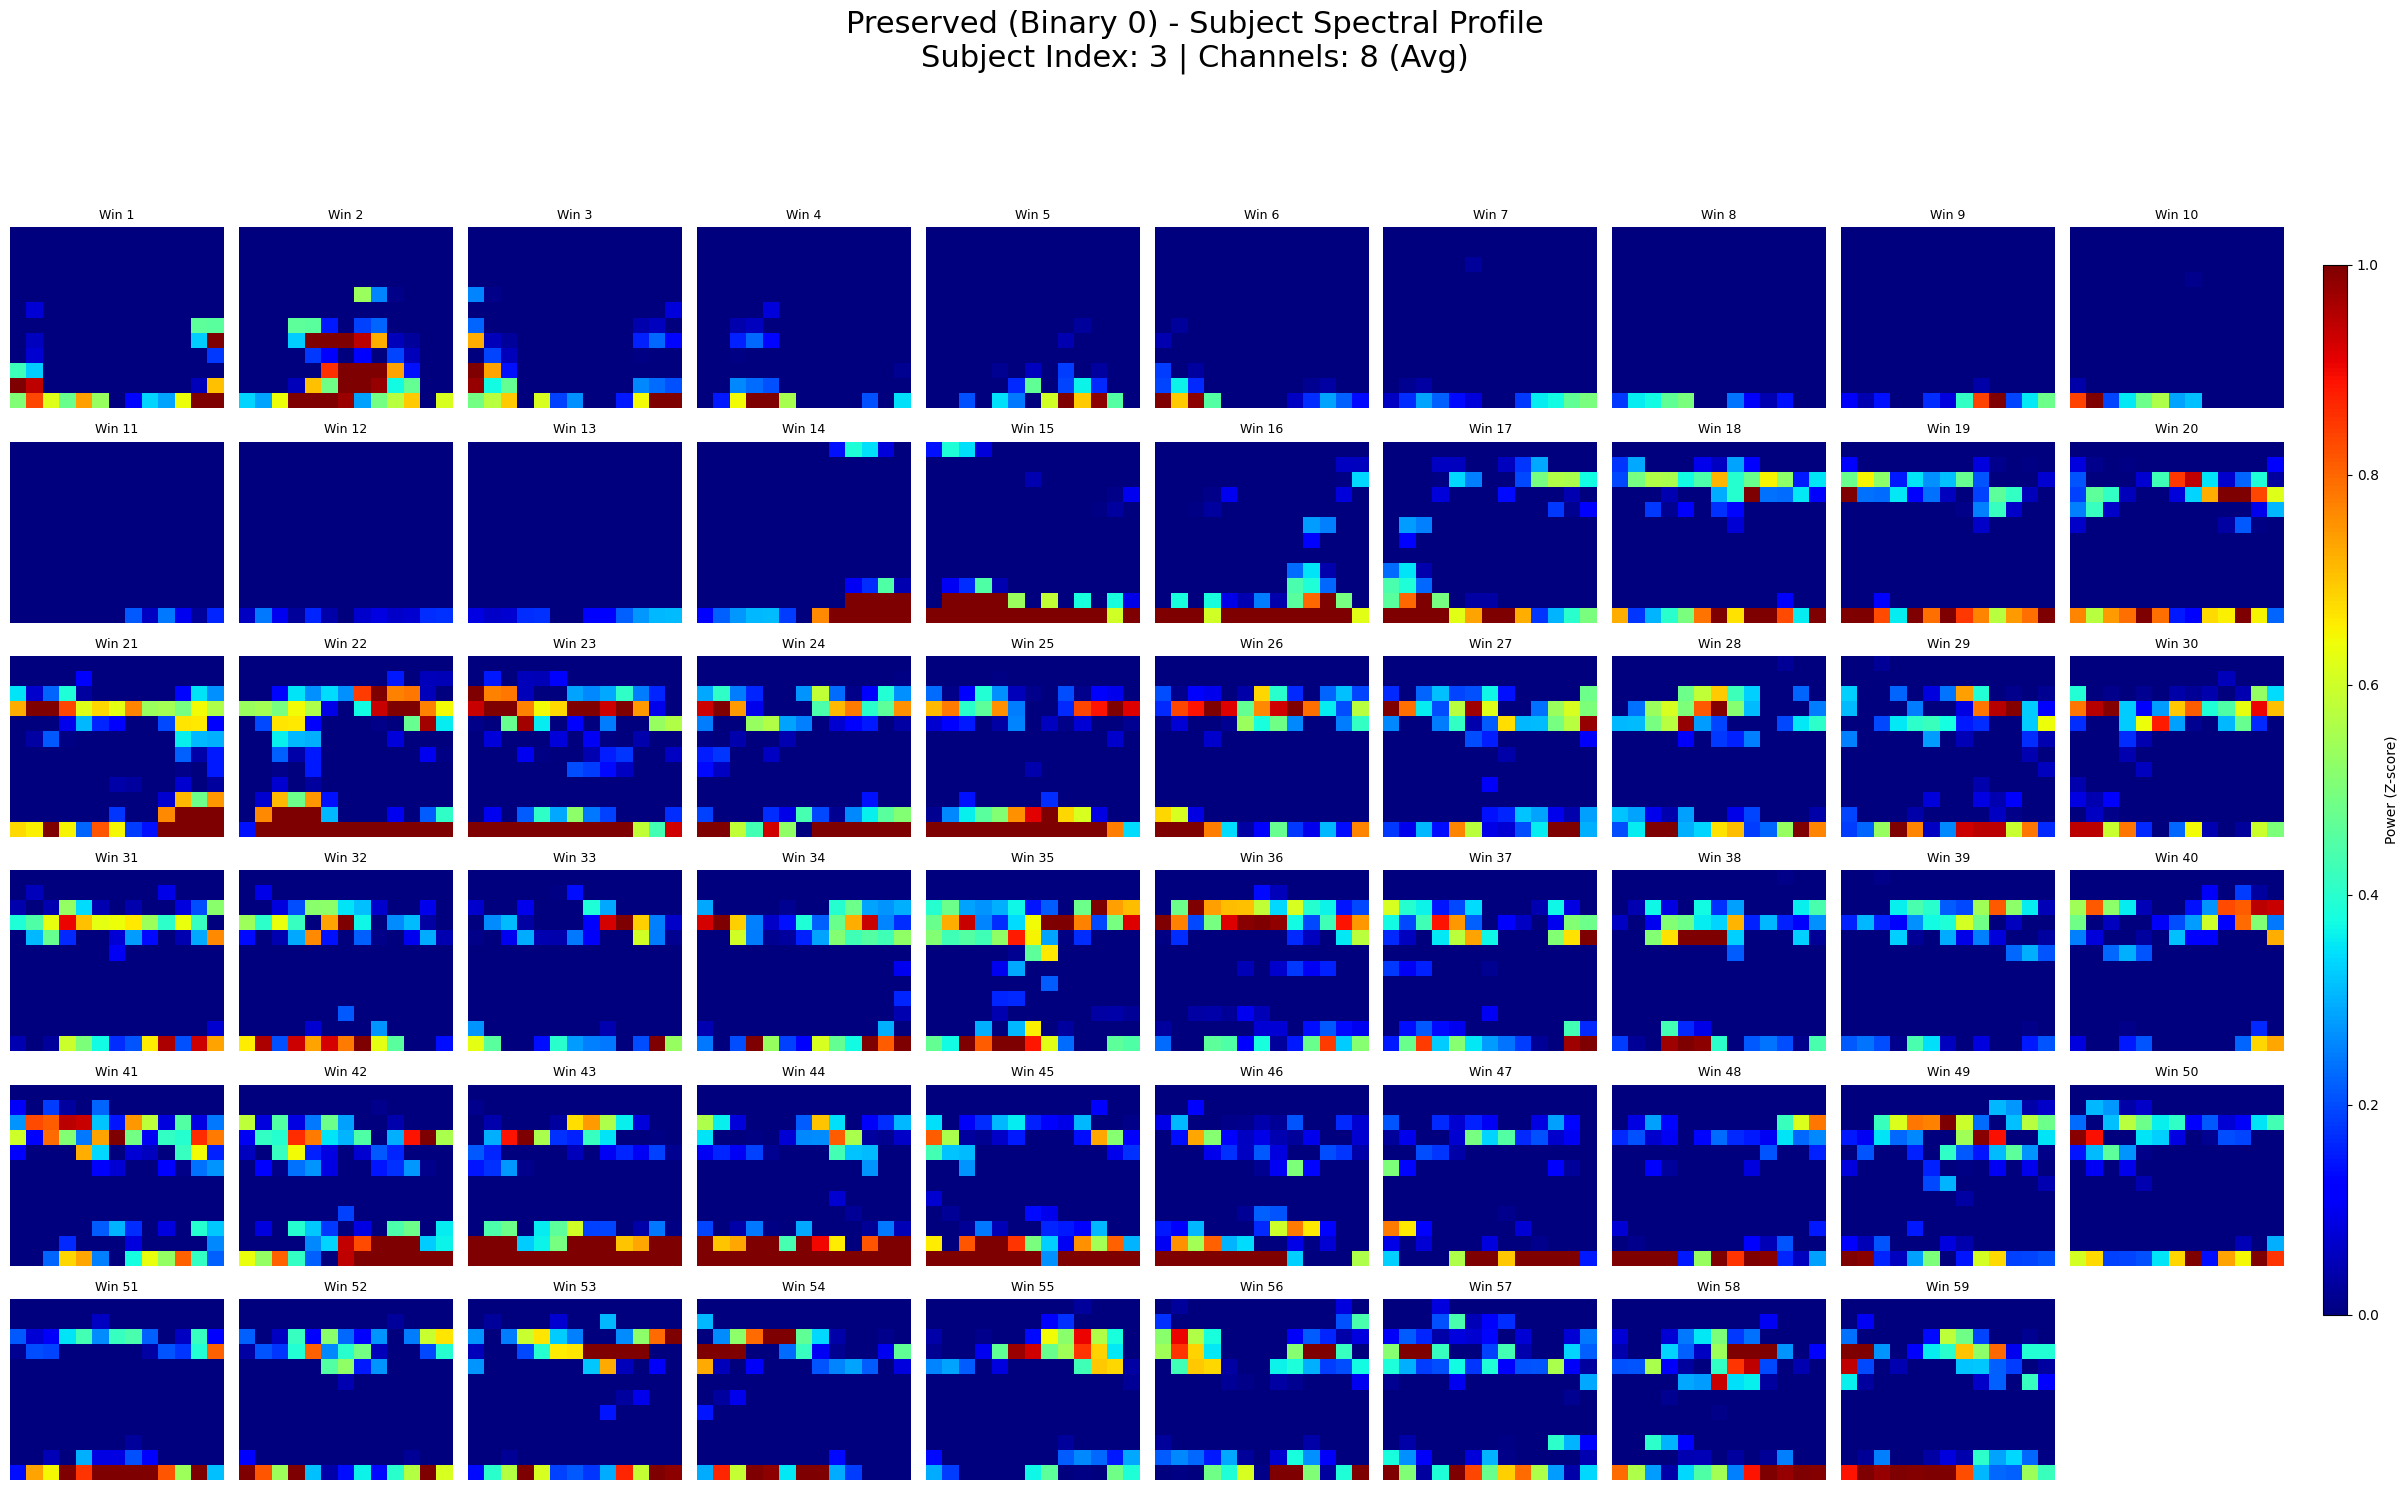

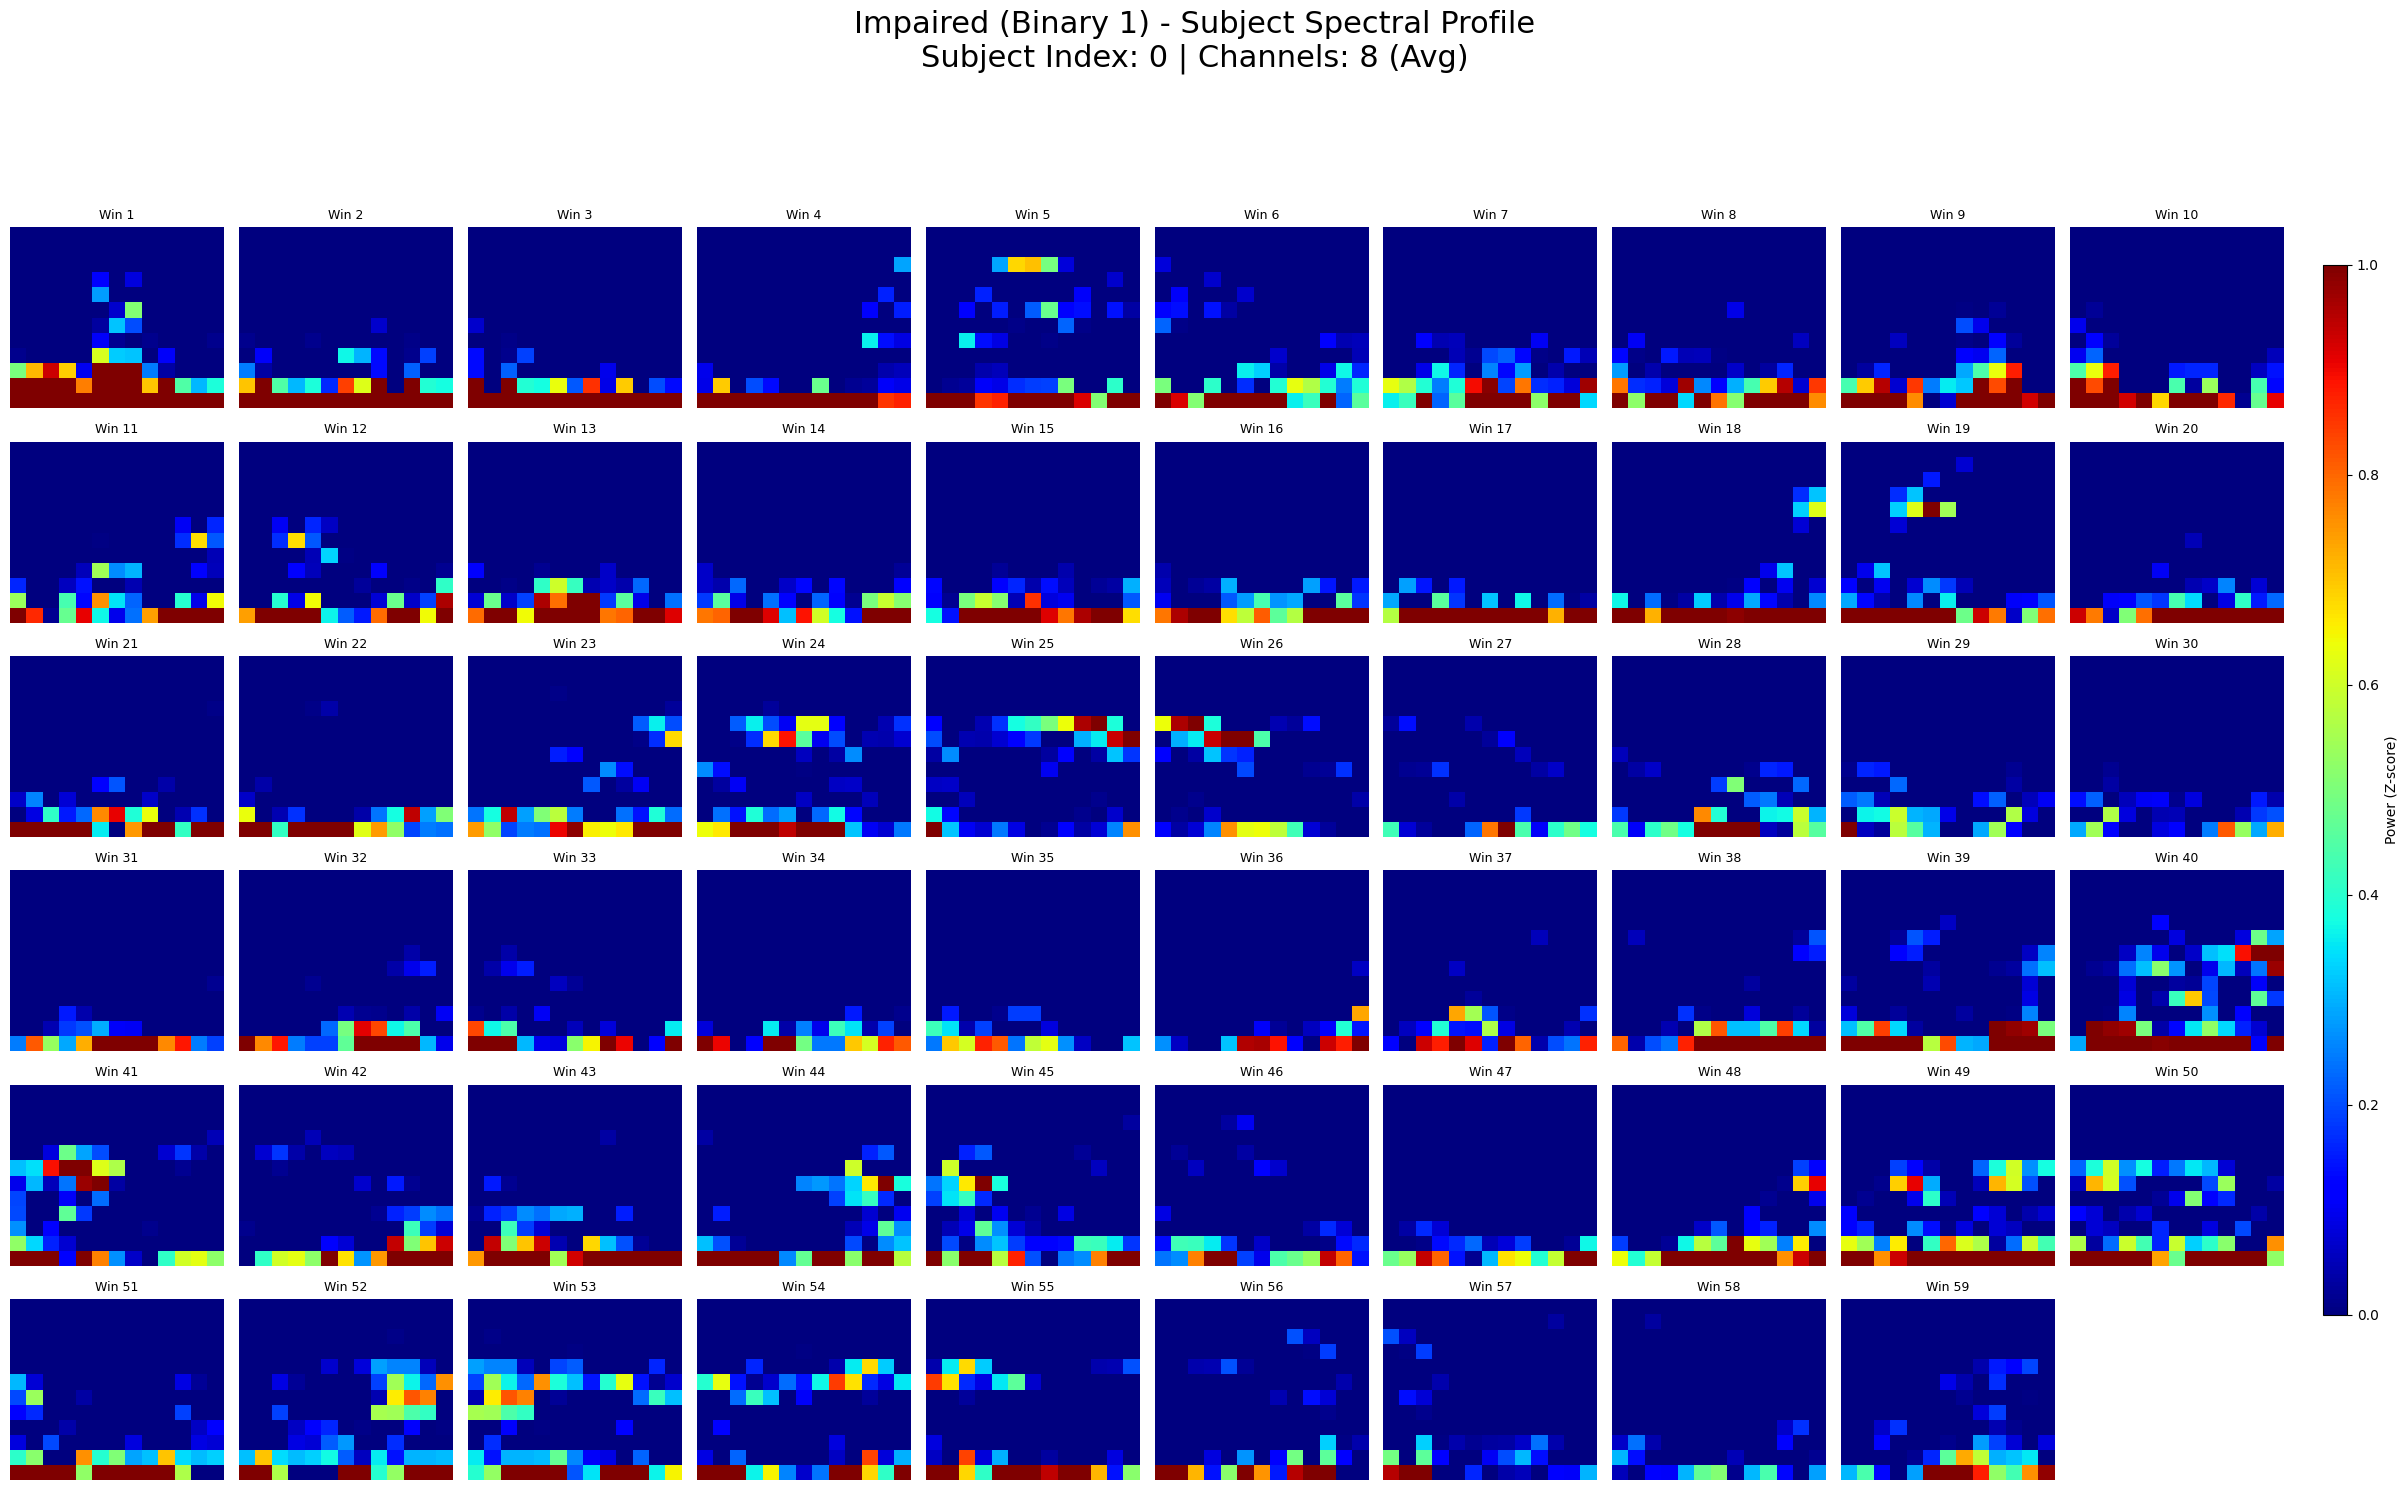

In [26]:
def plot_subject_examples(target_label, title_prefix, label_array=y_cnn):#plot the different examples of subject's spectrograms with different labels

    # Find the first subject belonging to the target class
    # We use label_array (defaults to binary) to find the match
    available_indices = np.where(label_array == target_label)[0]
    if len(available_indices) == 0:
        print(f"No subjects found for label {target_label}")
        return

    subj_id_val = groups_cnn[available_indices[0]]
    indices = np.where(groups_cnn == subj_id_val)[0]

    n_windows = len(indices)
    n_cols = 10
    n_rows = (n_windows // n_cols) + 1

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, n_rows * 2.5))
    fig.suptitle(f"{title_prefix} - Subject Spectral Profile\nSubject Index: {subj_id_val} | Channels: 8 (Avg)",
                 fontsize=22, y=1.02)

    for i in range(n_rows * n_cols):
        row = i // n_cols
        col = i % n_cols
        ax = axes[row, col]

        if i < n_windows:#chose window index
            idx = indices[i]
            # Averaging across the 8 cognitive channels for visualization
            combined_channels = X_cnn[idx].mean(axis=0)

            img = ax.imshow(combined_channels, aspect='auto', origin='lower',
                           cmap='jet', vmin=0, vmax=1)
            ax.set_title(f"Win {i+1}", fontsize=9)
        ax.axis('off')

    plt.tight_layout(rect=[0, 0.03, 0.96, 0.95]) #picture size for visuaization
    cbar_ax=fig.add_axes([0.97, 0.15, 0.01, 0.7])
    fig.colorbar(img, cax=cbar_ax, label='Power (Z-score)')
    plt.show()


plot_subject_examples(target_label=0, title_prefix="Preserved (Binary 0)")
plot_subject_examples(target_label=1, title_prefix="Impaired (Binary 1)")

In [27]:
print(X_cnn.shape)#to check that several spectograms really created per subject
print(y_cnn.shape)
print(len(groups_cnn))

(7729, 8, 12, 13)
(7729,)
7729


First of all, we transformed full EEG recordings into image-like spectrograms, in the purpose to allow CNNs to learn spatial and temporal cognitive patterns. Therefore we  applied a 0.5-12 Hz band-pass filter to focus on relevant cognitive frequencies that are associated with cognitive impairment in Parkinson’s disease patients. However, with only 149 participants, training the CNN on full-length EEG spectrograms resulted in very low validation accuracy, indicating poor generalization. For this reason, we transformed the recordings into spectrograms and applied 4-second windowing, increasing the number of samples to approximately 8000, meaning that every sample had several spectrograms. The CNN input was defined as (8 Electrodes × Time × Frequency), capturing spatial, temporal, and spectral information. The advantage of this windowing is the ability to increase the data set by using the samples themself without adding the synthetic data, and at the same time to save the frequency pattern of cognitive functioning within the samples. The aim of applying CNN to EEG spectrograms is to investigate whether objective neuro-physiological and spectral patterns, or previously unidentified features associated with cognitive decline can be detected, without relying on subjective clinical scores like Moca. Transforming  EEG to image-like spectrograms enables the model to capture dynamic frequency-time changes that are not detectable in other methods. This approach can provide a rapid, objective  and non-invasive diagnostic tool for assessing cognitive status of patients relying on its biological markers.



## Training and testing

In [28]:
cnn_nepochs=350
cnn_learning_rate=5e-5 #learning rate

class ConvolutionalNet(nn.Module):
  def __init__(self):
    super(ConvolutionalNet, self).__init__()
    # Layer 1: Sees the big picture (5x5)
    self.conv1 = nn.Conv2d(8, 16, kernel_size=5, padding=2)
    self.bn1 = nn.BatchNorm2d(16)

    # Layer 2: Sees the details (3x3)
    self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
    self.bn2 = nn.BatchNorm2d(32)

    # Layer 3: Refines the features (3x3)
    self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.bn3 = nn.BatchNorm2d(64)

    self.pool = nn.AvgPool2d(2)
    self.dropout = nn.Dropout(0.5)
    self.adaptive_pool = nn.AdaptiveMaxPool2d(1)
    self.fc = nn.Linear(64, 1)

  def forward(self, x):
    x = F.relu(self.bn1(self.conv1(x)))
    x = self.pool(x)
    x = F.relu(self.bn2(self.conv2(x)))
    x = self.pool(x)
    x = F.relu(self.bn3(self.conv3(x)))
    x = self.dropout(x)
    x = self.adaptive_pool(x)
    x = x.view(x.size(0), -1)
    return self.fc(x).view(-1)

model=ConvolutionalNet()

We applied a very simple CNN model with only three convolutional layers, because more complicated architectures can lead to overfitting in such sensitive data. In addition, we used 5X5 and 3X3 size kernels, which showed the best  performance among tested kernel sizes. The initial layer employs a larger 5X5 kernel for 16  filters to capture broad spectral features, while other layers use 3X3 kernels enabling the model to capture  small and specific patterns on spectrograms. For the first convolutional layer we used 16 filters to capture basic spectrogram patterns, and then 32 and 64 filters on the following convolutional layer to capture more complex spatial interactions, while keeping the number of parameters low.  In addition, Adaptive Max pooling significantly reduced the total parameter count ensuring that the model remains as simple as possible. This architecture simplicity, combined with Batch normalization and Dropout, ensures that the model learns robust, generalizable biomarkers rather than noise.


### Evaluation Structure

Cross-Validation (GroupKFold) is used to estimate model robustness and stability across different train/validation splits.
The final reported performance comes from the holdout test set, that is a fixed subset of subjects that were never seen during training or validation. Subject-level accuracy, balanced accuracy, and other metrics reported below are computed only on this held-out test set.

In [29]:
# Tensors
X_tensor = torch.tensor(X_cnn)
y_tensor = torch.tensor(y_cnn).view(-1, 1)
y_tier_tensor = torch.tensor(y_tier_cnn).view(-1, 1)
full_dataset = TensorDataset(X_tensor, y_tensor, y_tier_tensor)

# Split and Balance
gss=GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=5) #Train size 80% and GroupShuffleSplit because same subject has about 30 spectograms and we need that all the spectograms of the same subject will be only in train or only in test
train_val_idx, test_idx = next(gss.split(X_cnn, y_cnn, groups=groups_cnn))

X_cnn_train_val, y_cnn_train_val=X_cnn[train_val_idx], y_cnn[train_val_idx]#samples indexes
groups_train_val=groups_cnn[train_val_idx]
X_cnn_test, y_cnn_test=X_cnn[test_idx], y_cnn[test_idx]

#train val split according to the groups
gss_val=GroupShuffleSplit(n_splits=1, train_size=0.85, random_state=5) #subject level split
t_relative_idx, v_relative_idx=next(gss_val.split(X_cnn_train_val, y_cnn_train_val, groups=groups_train_val))
X_cnn_train, y_cnn_train=X_cnn_train_val[t_relative_idx], y_cnn_train_val[t_relative_idx] #appearance of the windows in train or in test
X_cnn_val, y_cnn_val =X_cnn_train_val[v_relative_idx], y_cnn_train_val[v_relative_idx]

#checking if every subject only in one group (train, val, test) because of several windows that creates several spectograms
train_subs = set(groups_train_val[t_relative_idx])
val_subs = set(groups_train_val[v_relative_idx])
print(f"Overlap check: {train_subs.intersection(val_subs)}")
print(f"Total samples in X_train: {X_cnn_train.shape[0]}") #checking how many samples there are now
print(f"Total samples in X_test: {X_cnn_test.shape[0]}")

train_dataset=Subset(full_dataset, train_val_idx[t_relative_idx])
val_dataset=Subset(full_dataset, train_val_idx[v_relative_idx])
test_dataset=Subset(full_dataset, test_idx)
train_loader=DataLoader(train_dataset, batch_size=32, shuffle=True)#create the loader
val_loader=DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader=DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Total samples in train_dataset: {len(train_dataset)}")#checking the nuber of samples after the split
sample_x, sample_y, _ = train_dataset[0]
print(f"Shape of one sample: {sample_x.shape}")

Overlap check: set()
Total samples in X_train: 5192
Total samples in X_test: 1593
Total samples in train_dataset: 5192
Shape of one sample: torch.Size([8, 12, 13])


In [30]:
# Use GroupKFold to keep subjects together
gkf = GroupKFold(n_splits=5)

# We split based on the subject indices we saved earlier
# This gives us 5 different "folds" to test the CNN's true reliability
folds = list(gkf.split(X_cnn, y_cnn, groups=groups_cnn))

In [31]:
def get_balanced_loader(dataset, indices, batch_size=32):
    # Get labels for the current subset
    subset_labels = y_cnn[indices]

    # Calculate weights: Higher weight for the smaller class (Preserved)
    class_sample_count = np.array([len(np.where(subset_labels == t)[0]) for t in np.unique(subset_labels)])
    weight = 1. / class_sample_count
    samples_weight = torch.from_numpy(np.array([weight[int(t)] for t in subset_labels])).float()

    sampler = WeightedRandomSampler(samples_weight, len(samples_weight))

    return DataLoader(Subset(dataset, indices), batch_size=batch_size, sampler=sampler)

# Example for Fold 1
train_idx, val_idx = folds[0]
train_loader = get_balanced_loader(full_dataset, train_idx)
val_loader = DataLoader(Subset(full_dataset, val_idx), batch_size=32, shuffle=False)

The data split to train, validation and test by Subject-Level split to prevent the data leakage. Thus, we used Group Shuffle Split to ensure that all spectrograms belonging to the same subject were assigned to the same group (test, validation or training).  
In addition we balanced the data with weight sampling (WeightedRandomSampler), giving less weight for larger groups (Impairment in our case), meaning that the same sample from the smaller group the model detects/sees several times


In [32]:
def train_model(model, optimizer, criterion, nepochs, train_loader, val_loader, is_image_input=False):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)#update learning rate every 3 epochs, if learning rate veryy high so devide an half
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict()) #save the best model
    early_stop_patience=15
    epochs_no_improve=0
    max_allowed_gap=0.15 #max generalization gap that allowed to continue the training
# Training loop
    for epoch in range(nepochs):
        model.train()
        running_train_loss = 0
        train_correct=0
        for inputs, labels, _ in train_loader:
            inputs, labels = inputs.to(device), labels.to(device).float().view(-1)
            optimizer.zero_grad()
            outputs = model(inputs).view(-1) #foward pass

            loss = criterion(outputs, labels) #compute loss function
            loss.backward() #backpropagation
            optimizer.step() #update the weights

            running_train_loss += loss.item()
            train_preds = (outputs > 0).float()
            train_correct += (train_preds == labels).sum().item() #how many times the model were right
    # Validation
        model.eval()
        runing_val_loss=0
        val_correct = 0
        with torch.no_grad():
            for inputs, labels, _ in val_loader:
                inputs, labels = inputs.to(device), labels.to(device).float().view(-1)
                outputs = model(inputs).view(-1)
                val_loss = criterion(outputs, labels)
                runing_val_loss+=val_loss.item()
                preds = (outputs > 0).float()
                val_correct += (preds == labels).sum().item()

        epoch_train_loss=running_train_loss/ len(train_loader)#compute avarage loss
        epoch_val_loss=runing_val_loss / len(val_loader)
        epoch_train_acc = train_correct / len(train_loader.dataset)#compute the persantage of accuracy
        epoch_val_acc=val_correct / len(val_loader.dataset)

        scheduler.step(epoch_val_loss)#for updating the learning rate

        train_losses.append(epoch_train_loss) #for learning curves representation and checking the overfitting
        val_losses.append(epoch_val_loss)
        train_accuracies.append(epoch_train_acc)
        val_accuracies.append(epoch_val_acc)

        if epoch_val_loss < best_val_loss:# to save the best model
           best_val_loss = epoch_val_loss
           epochs_no_improve = 0
           best_model_wts = copy.deepcopy(model.state_dict())
        else:
            epochs_no_improve += 1


        #check generalization gap
        gap = epoch_val_loss - epoch_train_loss
        if gap > max_allowed_gap and epoch > 10:
            print(f"Stopping because gap ({gap:.4f}) exceeded limit ({max_allowed_gap})")
            break #stop train if the gap is too high
        if epochs_no_improve >= early_stop_patience:#if get 15 petience without improving, stops
             print(f"Early stopping triggered at epoch {epoch+1}, No improvement for {early_stop_patience} epochs")
             break

        if (epoch + 1) % 5 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch+1}/{nepochs}: Train Loss {epoch_train_loss:.4f}, Val Loss {epoch_val_loss:.4f}, Val Acc {epoch_val_acc:.3f}")
    model.load_state_dict(best_model_wts)
    return model, train_losses, val_losses, train_accuracies, val_accuracies

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvolutionalNet().to(device)
cnn_optimizer = torch.optim.Adam(model.parameters(), lr=cnn_learning_rate, weight_decay=5e-3)
cnn_criterion = nn.BCEWithLogitsLoss()

model, train_losses, val_losses, train_accuracies, val_accuracies = train_model(model, cnn_optimizer, cnn_criterion,
                                       nepochs=cnn_nepochs, train_loader=train_loader, val_loader=val_loader, is_image_input=False) #train the model

Epoch 5/350: Train Loss 0.5206, Val Loss 0.6150, Val Acc 0.661
Epoch 10/350: Train Loss 0.4632, Val Loss 0.5818, Val Acc 0.710
Stopping because gap (0.1570) exceeded limit (0.15)


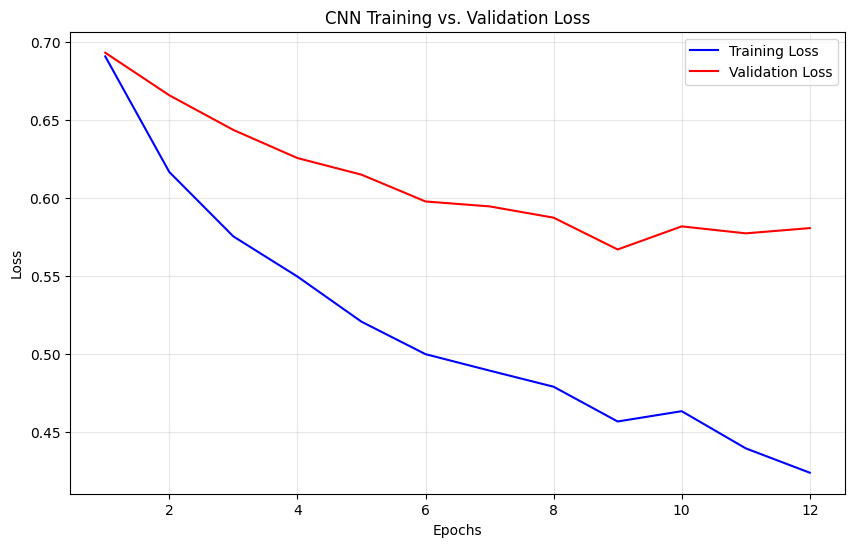

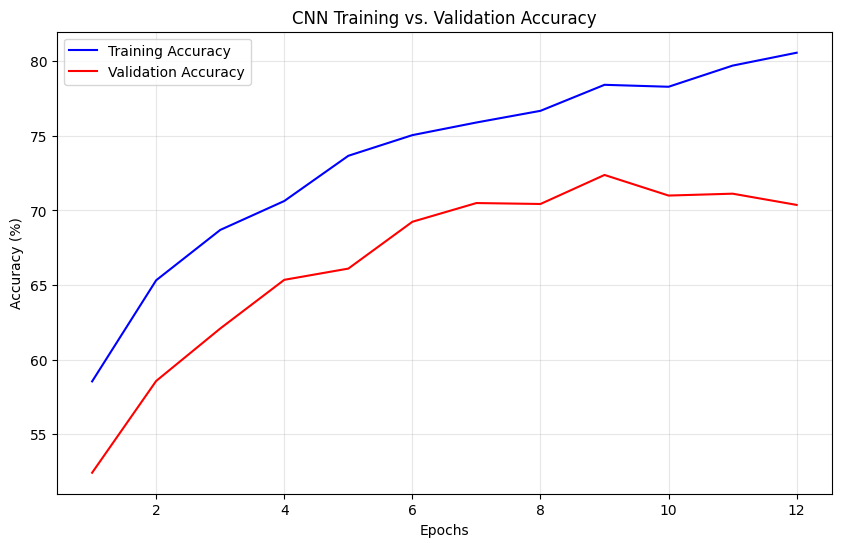

In [47]:
epochs = range(1, len(train_losses) + 1) #plot train and validation loss as a function of #epochs
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, label="Training Loss", color='blue')
plt.plot(epochs, val_losses, label="Validation Loss", color='red')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("CNN Training vs. Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6)) #where the best accuracy was
plt.plot(epochs, [a*100 for a in train_accuracies], label="Training Accuracy", color='blue')
plt.plot(epochs, [a*100 for a in val_accuracies], label="Validation Accuracy", color='red')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("CNN Training vs. Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Primary Evaluation Metric

Subject-level classification is the primary evaluation metric: each subject receives a single prediction (mean of window probabilities), and accuracy, balanced accuracy, sensitivity, specificity, and ROC-AUC are computed at the subject level. Window-level metrics used only to assess training stability.

In [57]:
def evaluate_model(model, val_loader):#evaluation in window level
    model.eval()
    correct = 0
    total = 0
    '''
  #Evaluate a model on the given dataloader.
  #Params:
  #model - a pytorch model to train
  #val_loader - dataloader for the valset
  '''
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    with torch.no_grad():#predictions
        for images, labels, _ in val_loader:
            images, labels = images.to(device), labels.to(device).float().view(-1)
            outputs = model(images).view(-1)
            predicted=(outputs > 0).float()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    return accuracy
val_acc=evaluate_model(model, val_loader)
print(f"Validation Accuracy: {val_acc:.2%}")

Validation Accuracy: 87.95%


In [58]:
def evaluate_model_at_subject_level(model, dataset, groups, device):
    model.eval()
    subj_results = {}

    with torch.no_grad():
        for i in range(len(dataset)):
            x, y, _ = dataset[i]
            subj_id = groups[i]
            output = model(x.unsqueeze(0).to(device))
            prob = torch.sigmoid(output).item()  #for convertion of logits to probability

            if subj_id not in subj_results:
                subj_results[subj_id] = {'probs': [], 'true': y.item()}
            subj_results[subj_id]['probs'].append(prob)

    # Aggregate votes
    final_true = []
    final_pred = []

    for s in subj_results:
        avg_prob = np.mean(subj_results[s]['probs'])
        final_pred.append(1 if avg_prob > 0.5 else 0)
        final_true.append(subj_results[s]['true'])
    return final_true, final_pred

#evaluation
# Subject-level classification on test set
test_groups = groups_cnn[test_idx]
true_vals, pred_vals = evaluate_model_at_subject_level(model, test_dataset, test_groups, device)

# Compute avgerage probs for ROC-AUC
subj_probs = {}
with torch.no_grad():
    for i in range(len(test_dataset)):
        x, y, _ = test_dataset[i]
        subj_id = test_groups[i]
        out = model(x.unsqueeze(0).to(device))
        prob = torch.sigmoid(out).item()
        if subj_id not in subj_probs:
            subj_probs[subj_id] = []
        subj_probs[subj_id].append(prob)
subj_order = list(subj_probs.keys())
avg_probs = [np.mean(subj_probs[s]) for s in subj_order]

print("Overall Subject-Level Performance (Primary Metric)")
print(f"Accuracy: {accuracy_score(true_vals, pred_vals):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(true_vals, pred_vals):.3f}")
cm = confusion_matrix(true_vals, pred_vals, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
print(f"Sensitivity (PD recall): {sensitivity:.3f}")
print(f"Specificity (Control recall): {specificity:.3f}")
print(f"ROC-AUC: {roc_auc_score(true_vals, avg_probs):.3f}")
print("\nDetailed Report:")
print(classification_report(true_vals, pred_vals, target_names=['Preserved', 'Impaired']))

Overall Subject-Level Performance (Primary Metric)
Accuracy: 0.852
Balanced Accuracy: 0.859
Sensitivity (PD recall): 0.875
Specificity (Control recall): 0.842
ROC-AUC: 0.849

Detailed Report:
              precision    recall  f1-score   support

   Preserved       0.94      0.84      0.89        19
    Impaired       0.70      0.88      0.78         8

    accuracy                           0.85        27
   macro avg       0.82      0.86      0.83        27
weighted avg       0.87      0.85      0.86        27



/tmp/ipykernel_1717/4032605186.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Clinical Tier', y='CNN Impairment Probability', data=df_res, order=order, palette="RdYlGn_r")


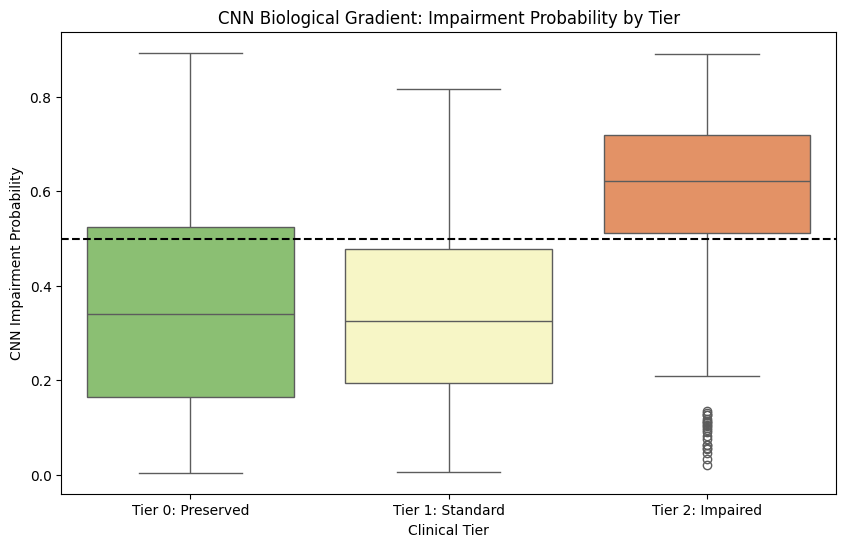

In [59]:
def plot_tiered_progression(model, test_loader):
  model.eval()
  tier_results = {0: [], 1: [], 2: []}

  with torch.no_grad():
    for inputs, _, tiers in test_loader:
      outputs = torch.sigmoid(model(inputs.to(device))).cpu().numpy().flatten()
      ts = tiers.numpy().flatten()
      for prob, t in zip(outputs, ts):
        tier_results[int(t)].append(prob)

  data = []
  tier_mapping = {0: 'Tier 0: Preserved', 1: 'Tier 1: Standard', 2: 'Tier 2: Impaired'}

  for t_idx, label in tier_mapping.items():
    for p in tier_results[t_idx]:
      data.append({'Clinical Tier': label, 'CNN Impairment Probability': p})

  df_res = pd.DataFrame(data)
  plt.figure(figsize=(10, 6))
  order = ['Tier 0: Preserved', 'Tier 1: Standard', 'Tier 2: Impaired']

  sns.boxplot(x='Clinical Tier', y='CNN Impairment Probability', data=df_res, order=order, palette="RdYlGn_r")
  plt.axhline(0.5, color='black', linestyle='--')
  plt.title("CNN Biological Gradient: Impairment Probability by Tier")
  plt.show()


plot_tiered_progression(model, test_loader)

The CNN Biological gradient plot shows overlap between Preserved and Impaired groups (both with median probabilities around 0.6), while Standard displays lower probabilities (0.4). This suggests that window-level features are shared across clinical groups, and the model struggles to clearly separate Preserved from Impaired subjects. The patterns are consistent with the CNN learning spatial-temporal structure that may relate to cognitive status, though physiological interpretation should be made cautiously.

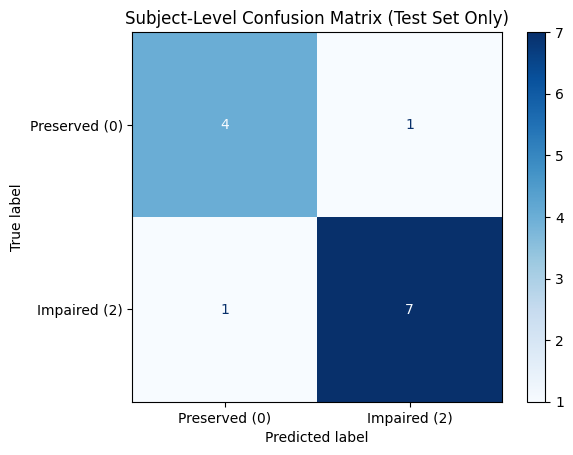

In [60]:
# Aggregate Subject Votes
subject_probs = {}
subject_true_tier = {}

model.eval()
with torch.no_grad():
    test_groups = groups_cnn[test_idx]
    for i in range(len(test_dataset)):
        inputs, _, tier = test_dataset[i]
        subj_id = test_groups[i]
        output = torch.sigmoid(model(inputs.unsqueeze(0).to(device))).item()  # Logits->prob

        if subj_id not in subject_probs:
            subject_probs[subj_id] = []
            subject_true_tier[subj_id] = tier.item()
        subject_probs[subj_id].append(output)

# Calculate final votes
final_results = []
for s in subject_probs:
    avg_prob = np.mean(subject_probs[s])
    final_results.append({
        'Subject': s,
        'True_Tier': subject_true_tier[s],
        'CNN_Vote': 1 if avg_prob > 0.5 else 0
    })

res_df = pd.DataFrame(final_results)

# Confusion Matrix for the clear cases (Tier 0 vs Tier 2)
binary_df = res_df[res_df['True_Tier'].isin([0, 2])]
# Map True_Tier 2 to 1 for the CM to match the CNN_Vote (0 or 1)
y_true = binary_df['True_Tier'].replace(2, 1)
y_pred = binary_df['CNN_Vote']

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Preserved (0)', 'Impaired (2)'])
disp.plot(cmap='Blues')
plt.title("Subject-Level Confusion Matrix (Test Set Only)")
plt.show()

In [61]:
results = [] #training of k-folds, cross validation

for fold_idx, (t_idx, v_idx) in enumerate(folds):
    print(f"Training Fold {fold_idx + 1}")
    t_loader = get_balanced_loader(full_dataset, t_idx)
    v_loader = DataLoader(Subset(full_dataset, v_idx), batch_size=32)
    model = ConvolutionalNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cnn_learning_rate)
    trained_model, train_losses, val_losses, train_accuracies, val_accuracies = train_model(model, optimizer, cnn_criterion, cnn_nepochs, t_loader, v_loader)
    results.append(max(val_accuracies))#save the best result

print(f"CV Window-Level Accuracy: {np.mean(results):.2f} ± {np.std(results):.2f} (mean ± std across {len(results)} folds)")
#check what is the accuracy when we mix the smples, and that accuracy we found not sample depend and there are no sample bias

Training Fold 1
Epoch 5/350: Train Loss 0.5154, Val Loss 0.5979, Val Acc 0.687
Epoch 10/350: Train Loss 0.4218, Val Loss 0.5913, Val Acc 0.689
Stopping because gap (0.1871) exceeded limit (0.15)
Training Fold 2
Epoch 5/350: Train Loss 0.5105, Val Loss 0.5426, Val Acc 0.769
Epoch 10/350: Train Loss 0.4325, Val Loss 0.5344, Val Acc 0.773
Epoch 15/350: Train Loss 0.4174, Val Loss 0.5538, Val Acc 0.761
Stopping because gap (0.1577) exceeded limit (0.15)
Training Fold 3
Epoch 5/350: Train Loss 0.4725, Val Loss 0.6914, Val Acc 0.526
Epoch 10/350: Train Loss 0.4157, Val Loss 0.7246, Val Acc 0.529
Stopping because gap (0.3345) exceeded limit (0.15)
Training Fold 4
Epoch 5/350: Train Loss 0.4808, Val Loss 0.6483, Val Acc 0.606
Epoch 10/350: Train Loss 0.4190, Val Loss 0.7191, Val Acc 0.574
Stopping because gap (0.3096) exceeded limit (0.15)
Training Fold 5
Epoch 5/350: Train Loss 0.4794, Val Loss 0.6532, Val Acc 0.625
Epoch 10/350: Train Loss 0.3858, Val Loss 0.6088, Val Acc 0.677
Stopping beca

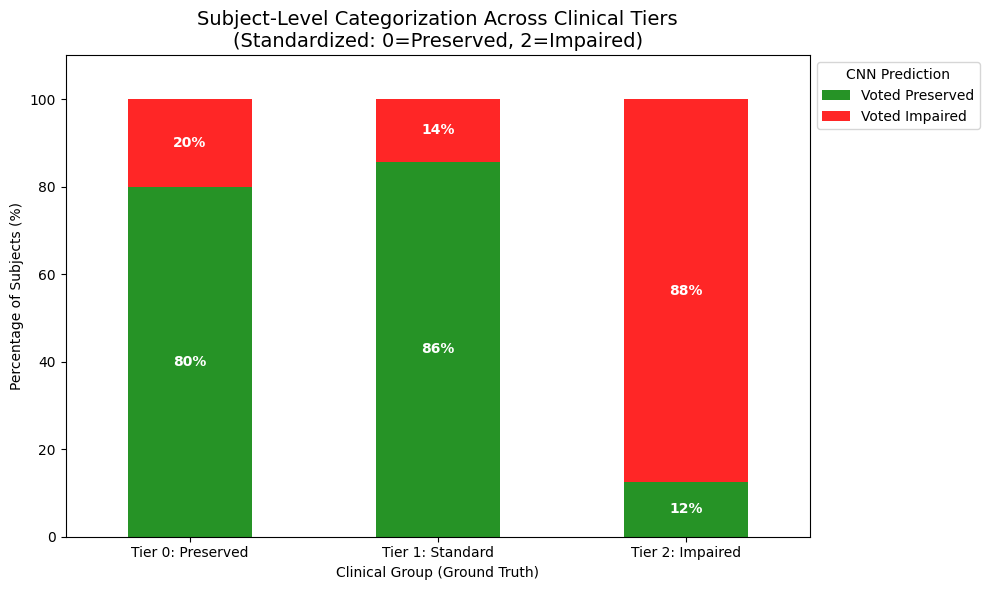

In [62]:
results_df = pd.DataFrame({
  'Subject': list(subject_probs.keys()),
  'Tier': [subject_true_tier[s] for s in subject_probs.keys()],
  'Avg_Prob': [np.mean(subject_probs[s]) for s in subject_probs.keys()]
})

# Define the prediction based on the 0.5 threshold
results_df['CNN_Vote'] = (results_df['Avg_Prob'] > 0.5).astype(int)

# Mapping for the X-axis (Clinical Tiers)
tier_map = {0: 'Tier 0: Preserved', 1: 'Tier 1: Standard', 2: 'Tier 2: Impaired'}
results_df['Tier_Label'] = results_df['Tier'].map(tier_map)

results_df['CNN_Decision'] = results_df['CNN_Vote'].map({0: 'Voted Preserved', 1: 'Voted Impaired'})

# Pivot Table
pivot_df = results_df.groupby(['Tier_Label', 'CNN_Decision']).size().unstack(fill_value=0)

for col in ['Voted Preserved', 'Voted Impaired']:
  if col not in pivot_df.columns:
    pivot_df[col] = 0

# %
# Plotting with logical clinical colors
pivot_df_perc = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100
pivot_df_perc = pivot_df_perc[['Voted Preserved', 'Voted Impaired']]
order = ['Tier 0: Preserved', 'Tier 1: Standard', 'Tier 2: Impaired']
pivot_df_perc = pivot_df_perc.reindex(order)

ax = pivot_df_perc.plot(
  kind='bar',
  stacked=True,
  figsize=(10, 6),
  color=['green', 'red'], # Green for Healthy, Red for Impaired
  alpha=0.85
)

plt.title("Subject-Level Categorization Across Clinical Tiers\n(Standardized: 0=Preserved, 2=Impaired)", fontsize=14)
plt.ylabel("Percentage of Subjects (%)")
plt.xlabel("Clinical Group (Ground Truth)")
plt.xticks(rotation=0)
plt.legend(title="CNN Prediction", loc='upper left', bbox_to_anchor=(1, 1))
plt.ylim(0, 110) # Bumped to 110 to give the top labels some breathing room

# Add percentage labels on the bars for clarity
for p in ax.patches:
  width, height = p.get_width(), p.get_height()
  if height > 5: # Only show label if the segment is visible
    x, y = p.get_xy()
    # Removed 'float_format', the formatting is handled by the f-string below
    ax.text(
      x + width/2,
      y + height/2,
      f'{height:.0f}%',
      ha='center',
      va='center',
      color='white',
      fontweight='bold'
    )

plt.tight_layout()
plt.show()


The model thinks the "Standard" group looks almost identical to the "Preserved" group.

In [63]:
def delong_roc_variance(y_true, prob):#delong statistic test for compairing AUC between the groups and its significance
    pos=prob[y_true == 1] #Impaired
    neg=prob[y_true == 0] #Preserved
    m, n = len(pos), len(neg)
    v1=(np.sum(pos[:, None] > neg, axis=1) + 0.5 * np.sum(pos[:, None] == neg, axis=1))/n #compute tha varience
    v0=(np.sum(neg[:, None] < pos, axis=1) + 0.5 * np.sum(neg[:, None] == pos, axis=1))/m
    return np.var(v1, ddof=1)/m + np.var(v0, ddof=1)/n

def compare_models_delong(y_true, prob_rf, prob_cnn):
    auc_rf=roc_auc_score(y_true, prob_rf) #AUC computing
    auc_cnn=roc_auc_score(y_true, prob_cnn)
    var_rf=delong_roc_variance(y_true, prob_rf)
    var_cnn=delong_roc_variance(y_true, prob_cnn)
    z_score=(auc_cnn - auc_rf) / np.sqrt(var_rf + var_cnn)#z-score computing
    p_value=2*stats.norm.sf(np.abs(z_score))#p-value computing
    return z_score, p_value, auc_rf, auc_cnn
# ROC vizualization
def plot_model_comparison(y_true, prob_rf, prob_cnn):
    z, p, auc_rf, auc_cnn = compare_models_delong(y_true, prob_rf, prob_cnn)
    fpr_rf, tpr_rf, _ = roc_curve(y_true, prob_rf)
    fpr_cnn, tpr_cnn, _ = roc_curve(y_true, prob_cnn)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='blue', linestyle='--')
    plt.plot(fpr_cnn, tpr_cnn, label=f'CNN (AUC = {auc_cnn:.3f})', color='red', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.title('ROC Curve Comparison: RF vs. CNN', fontsize=14)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    stats_text = f"DeLong Test:\nZ-score: {z:.2f}\nP-value: {p:.4f}"
    plt.text(0.5, 0.2, stats_text, bbox=dict(facecolor='white', alpha=0.8))
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.savefig('roc_comparison.png')


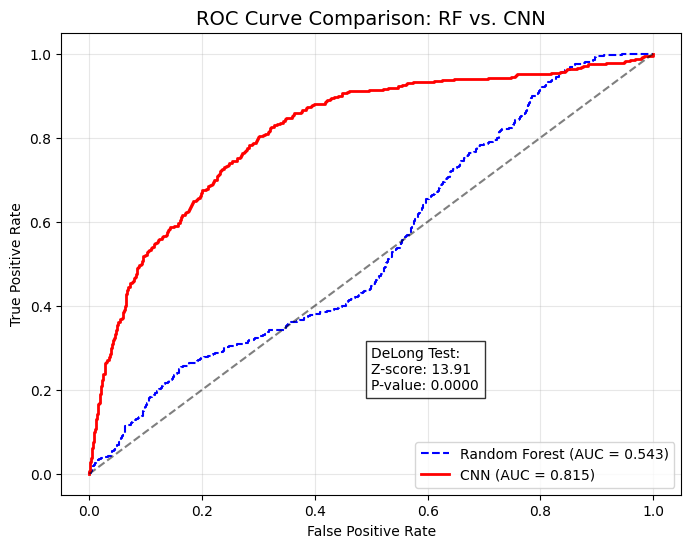


Statistical decision
CNN AUC: 0.8152
RF AUC:  0.5426
P-value: 5.350389e-44


In [64]:
model.eval()
cnn_probs_all = []
y_true_all = []

with torch.no_grad():
    for inputs, labels, _ in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = torch.sigmoid(outputs).cpu().numpy().flatten()  # convert to probabilities for ROC
        cnn_probs_all.extend(probs)
        y_true_all.extend(labels.numpy().flatten())

y_true_all = np.array(y_true_all)
cnn_probs_all = np.array(cnn_probs_all)
#Random forest
X_rf_train = X_cnn_train.reshape(len(X_cnn_train), -1) #changing of traing/test values for RF usage
X_rf_test = X_cnn_test.reshape(len(X_cnn_test), -1)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=7)
rf_model.fit(X_rf_train, y_cnn_train)
rf_probs_all = rf_model.predict_proba(X_rf_test)[:, 1]

if len(rf_probs_all) != len(cnn_probs_all):
    min_len = min(len(rf_probs_all), len(cnn_probs_all))
    y_true_all = y_true_all[:min_len]
    rf_probs_all = rf_probs_all[:min_len]
    cnn_probs_all = cnn_probs_all[:min_len]

try:
    plot_model_comparison(y_true_all, rf_probs_all, cnn_probs_all)
    plt.show()
except Exception as e:
    print(f"Error: {e}")

# final statistical decision
z, p, auc_rf, auc_cnn = compare_models_delong(y_true_all, rf_probs_all, cnn_probs_all)
print(f"\nStatistical decision")
print(f"CNN AUC: {auc_cnn:.4f}")
print(f"RF AUC:  {auc_rf:.4f}")
print(f"P-value: {p:.6e}")

The CNN receives spectrogram tensors (8 electrodes x Time x Frequency), preserving spatial structure. The Random Forest receives the same data flattened into a feature vector, so it cannot exploit spatial relationships between channels. Both models are trained on the same spectrograms, the comparison assesses whether deep learning adds value by learning spatial patterns.
We have 149 participants with about 8000 spectrograms. The DeLong test compares AUCs of the Spectrogram CNN vs Random Forest baseline. RF was chosen because it cannot use spatial information (channel power), allowing us to assess whether deep learning adds discriminative ability by learning spatial patterns.
The ROC curve illustrates the trade-off between True Positive Rate and False Positive Rate across thresholds. A higher curve indicates superior separability. The CNN suggests higher separability than RF, with a low p-value supporting the AUC difference. The CNN demonstrates significantly higher AUC (p<0.001).
These results suggest that complex spatial-temporal patterns in EEG of Parkinson patients may be better captured by CNN than by traditional methods. A deep learning approach appears promising for cognitive-based PD classification.


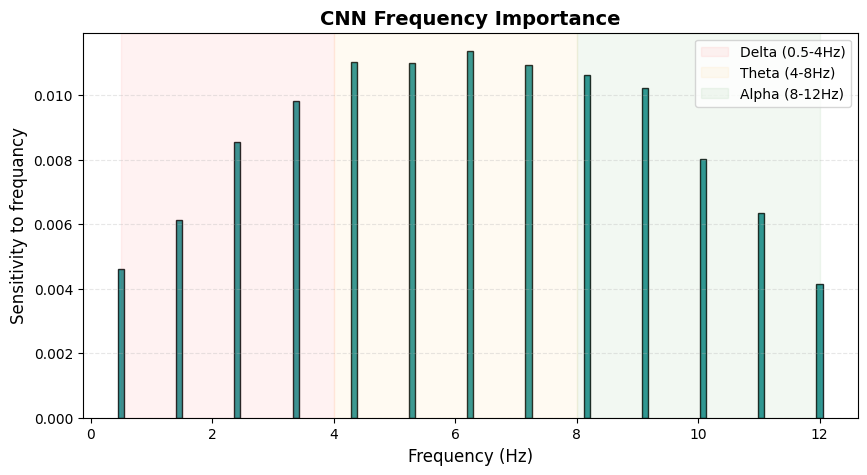

In [65]:
#which spesific frequancies cause to CNN to  chouse if the sample in one group or another
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()
ig = IntegratedGradients(model)#measure the contribution of each input feature to model output, comput gradient for every step and integrates them
plt.clf()
plt.close('all')

test_input = torch.tensor(X_cnn_test[:100]).float().to(device)
test_input.requires_grad_()

#feature contribution to the model acording to test
attributes = ig.attribute(test_input, target=None)
importance_per_feature = attributes.abs().mean(dim=(0, 1, 2)).detach().cpu().numpy()


freq_axis = np.linspace(0.5, 12, len(importance_per_feature))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(freq_axis, importance_per_feature, width=0.1, color='teal', edgecolor='black', alpha=0.8)
ax.axvspan(0.5, 4, color='red', alpha=0.05, label='Delta (0.5-4Hz)')
ax.axvspan(4, 8, color='orange', alpha=0.05, label='Theta (4-8Hz)')
ax.axvspan(8, 12, color='green', alpha=0.05, label='Alpha (8-12Hz)')
ax.set_title("CNN Frequency Importance", fontsize=14, fontweight='bold')
ax.set_xlabel("Frequency (Hz)", fontsize=12)
ax.set_ylabel("Sensitivity to frequancy", fontsize=12)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

To explain our statistical results and the physiological basis, we applied integrated gradients to identify the specific spectral patterns the model prefers. We can observe that the most influential and important frequencies are around 4-7 HZ, which are associated with Theta bands. This evidence means that the model relies mostly on relevant EEG signal markers, rather than learning just random noise, providing a physiological explanation for classification decisions.

In conclusion, CNN model demonstrates potential in classifying between different cognitive levels of PD and healthy controls. Although the model remains generalization gap and overfitting, the main reason for that could be the same window patterns from the same subjects after increasing the sample size by dividing the whole subject windows into several samples. The model’s performance on a 3-label testing and statistical analysis indicates a possible ability to capture physiological patterns, suggesting that with a larger and more diverse dataset, this approach could achieve more robust separability.